# [20480-02 Artificial Intelligence] <br> Final Project

Written by Dohee Kim, Kyunghee Kim, Artificial General Intelligence Laboratory, Ewha Womans University (Adapted from DSAIL @SNU).
This material is for educational uses only. Some contents are based on the material provided by other paper/book authors and may be copyrighted by them.

## Optional: Mount Google Drive in Colab

If you would like to save your work and access files directly from your Google Drive, you can mount your Drive in Google Colab using the following commands:

    from google.colab import drive
    drive.mount('/content/drive')

    %cd /content/drive/MyDrive/2026_01_AI/FinalProject

This step allows you to work on project files stored in Google Drive and ensures that your progress is preserved across Colab sessions.

**Note**: This step is completely optional. If you prefer to work only within the Colab environment or upload files manually, you may skip this section and proceed with the project normally.

# Task: Visual Question Answering (VQA) with Visual Token Compression

The objective of this project is to develop an **Effective Visual Token Compression** algorithm.
You will be working with a Vision-Language Model (VLM), specifically **LLaVA-Phi-3-Mini**, to perform Visual Question Answering (VQA).

The model processes images as a sequence of visual tokens. However, not all tokens contribute equally to the final answer. Your goal is to design a selection strategy that **reduces the number of visual tokens** (improving efficiency) while **maintaining the model's accuracy** on the VQA task.

### 1. Environment Setup & Model Loading (Fixed)
We begin by setting up the compute device and loading the **LLaVA-Phi-3-Mini** model.

In this step, we use `from_pretrained` with a specific **`cache_dir`**. This ensures that the model weights are downloaded to and loaded from a local `./checkpoint` directory, making the project self-contained and easier to manage.

* **Device**: Automatically selects `cuda` (GPU) if available.
* **Precision**: Loads weights in `torch.bfloat16` to optimize VRAM usage.
* **Patch Size**: We explicitly verify the patch size (14) which is crucial for calculating token counts later.



**Note**: The following cell defines the model, processor, and image preprocessing configuration used throughout the project.
**Do not modify any code in this cell.**

To ensure a fair comparison across all submissions, the following components must remain fixed:

* Model architecture
* Model checkpoint
* Processor configuration
* Patch size
* Image preprocessing settings (e.g., image resolution, cropping)

**Any modifications to this cell may result in inconsistent evaluation and are not allowed.**

The task is to design a visual token compression algorithm after the visual tokens have been extracted, reducing the number of visual tokens from 576 to 64 while preserving VQA performance as much as possible.

In [1]:
from google.colab import drive
drive.mount('/content/drive')

%cd /content/drive/MyDrive/2026_01_AI/FinalProject

Mounted at /content/drive
/content/drive/MyDrive/2026_01_AI/FinalProject


In [2]:
# 0. Install the required transformers version
!pip install -q transformers==4.57.2

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.0/44.0 kB 3.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.0/12.0 MB 84.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 566.4/566.4 kB 40.0 MB/s eta 0:00:00


In [3]:
import torch
import requests
from PIL import Image
from transformers import AutoProcessor, LlavaConfig
from utils.modeling_llava import LlavaForConditionalGeneration
from utils.utils import restore_image_from_tensor, visualize_selected_tokens, compress_inputs_for_num_vis_tokens

# 1. GPU Setup
device = "cuda" if torch.cuda.is_available() else "cpu"

# 2. Download and Load Model & Processor
cache_dir = "./checkpoint/llava-phi-3-mini-hf"
model_id = "xtuner/llava-phi-3-mini-hf"
model = LlavaForConditionalGeneration.from_pretrained(
    model_id,
    cache_dir=cache_dir,
    dtype=torch.bfloat16,
    low_cpu_mem_usage=True,
    trust_remote_code=True,
).to(device)

processor = AutoProcessor.from_pretrained(model_id, cache_dir=cache_dir, trust_remote_code=True)
processor.patch_size = 14

# NOTE: Code modification for center crop issue.
processor.image_processor.do_center_crop = False
processor.image_processor.size = (336, 336)

print("Model loaded.")

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


Loading checkpoint shards:   0%|          | 0/2 [00:00<?, ?it/s]

preprocessor_config.json:   0%|          | 0.00/819 [00:00<?, ?B/s]

Using a slow image processor as `use_fast` is unset and a slow processor was saved with this model. `use_fast=True` will be the default behavior in v4.52, even if the model was saved with a slow processor. This will result in minor differences in outputs. You'll still be able to use a slow processor with `use_fast=False`.


Model loaded.


### 2. Data Loading & Inspection
We load the VQA dataset, which consists of image-question pairs with multiple-choice options.
In this step, we parse a sample entry to visualize the input image and the corresponding question. This helps in understanding the context the model needs to capture.

* **Input:** Image + Text Prompt (Question + Options)
* **Task:** Identify the correct option (A, B, etc.)

**Note**: This cell is provided for sanity checking and visualization only. Any changes made to this cell will NOT affect your evaluation score.


Question:
Is the ground completely covered by red fallen leaves?

Choices: 
A) Yes
B) No
Answer:
A


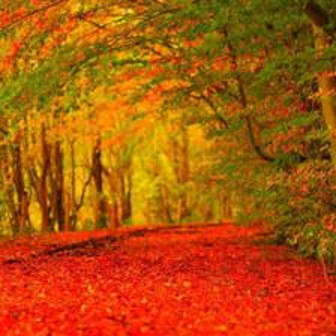

In [29]:
import json
import os
from utils.eval_utils import parse_sample, get_response, get_options_map, extract_option

with open('data/annotations.json', 'r') as f:
    data = json.load(f)

data_index = 0  # Example index
inputs, question, answer, sample_id = parse_sample(data, data_index, processor, device)

restored_iamge = restore_image_from_tensor(inputs['pixel_values'][0], processor.image_processor)
print(question)
print("Answer:")
print(answer)
display(restored_iamge)

### 3. Implement Your Token Selection Algorithm (Core Task)

This is the main part of the assignment. You need to implement a strategy to select the most informative visual tokens.

**Key Components:**
1.  **`num_vis_tokens`**: The budget of tokens you are allowed to use. Lower values mean higher compression/efficiency. (must be fixed)
2.  **`select_image_tokens`**: **(📝 Student Task)** You must implement this function. It takes the full set of image features and returns the indices of the selected tokens.
3.  **Monkey Patching**: We dynamically replace the model's original feature extraction method (`get_image_features`) with your custom `get_compressed_image_features`. This allows us to inject your compression logic without modifying the library code.

**Your Goal:** Replace the random selection example with your own logic (e.g., attention-based, gradient-based, or clustering-based selection).

In [30]:
### Do not modify any code in this cell

model.num_vis_tokens = 64  # example number of visual tokens
model.model.num_vis_tokens = model.num_vis_tokens  # Ensure inner model uses the same setting

#### 💡 Example Strategy: Random Selection
The code below demonstrates a **Naive/Random Selection** strategy.
It simply picks `num_vis_tokens` random indices from the total available tokens.

**Instructions:**
* Analyze the `select_image_tokens` function in the cell above.
* Note how it uses `torch.randperm` to select indices.
* **Your task is to replace this logic with a smarter algorithm.**

**Small Tip**: In your report, briefly explain the intuition behind your method, how it differs from the random selection baseline, and why it is expected to preserve more useful visual information for VQA.

In [31]:
from typing import Optional, Union


# =================================================================
# ToDo: Implement your token selection algorithm here
# =================================================================
# The evaluation uses 64 visual tokens.
# Do not change the number of selected tokens.
def select_image_tokens(image_features, num_vis_tokens=64, global_features=None):
    """
    Hybrid Top-k + Spatial CLS-Norm Selection, 32:32

    - Treat 576 visual tokens as a 24 x 24 grid.
    - Score = normalized feature norm + 1.5 * normalized CLS similarity.
    - Select 32 tokens using global top-k.
    - Select 32 tokens using spatial block selection.
    - Remove duplicates and fill missing tokens using score ranking.
    - Total selected tokens: 64.
    """
    batch_size = image_features.shape[0]
    num_image_tokens = image_features.size(1)
    device = image_features.device

    ##### **** Replace Your Algorithm Here **** #####

    features_f = image_features.float()

    def zscore(x):
        return (x - x.mean(dim=1, keepdim=True)) / (
            x.std(dim=1, keepdim=True) + 1e-6
        )

    norm_scores = features_f.norm(dim=-1)
    norm_scores = zscore(norm_scores)

    if global_features is not None:
        global_f = global_features.float()

        if global_f.dim() == 3:
            global_f = global_f.squeeze(1)

        img_norm = features_f / (
            features_f.norm(dim=-1, keepdim=True) + 1e-6
        )

        cls_norm = global_f / (
            global_f.norm(dim=-1, keepdim=True) + 1e-6
        )

        cls_scores = torch.bmm(
            img_norm,
            cls_norm.unsqueeze(-1)
        ).squeeze(-1)

        cls_scores = zscore(cls_scores)

    else:
        cls_scores = torch.zeros(
            batch_size,
            num_image_tokens,
            device=device
        )

    scores = norm_scores + 1.5 * cls_scores

    grid_size = int(num_image_tokens ** 0.5)

    if grid_size * grid_size != num_image_tokens:
        return torch.topk(scores, k=num_vis_tokens, dim=1).indices

    selected_all = []

    top_k_count = 32

    # 8 x 4 = 32 spatial regions.
    # For a 24 x 24 grid, each block is 3 x 6.
    row_blocks = 8
    col_blocks = 4

    if grid_size % row_blocks != 0 or grid_size % col_blocks != 0:
        return torch.topk(scores, k=num_vis_tokens, dim=1).indices

    row_block_size = grid_size // row_blocks
    col_block_size = grid_size // col_blocks

    for b in range(batch_size):
        s = scores[b]

        # 1. Global top-k selection
        top_indices = torch.topk(
            s,
            k=top_k_count,
            dim=0
        ).indices

        # 2. Spatial coverage selection
        spatial_indices = []

        for by in range(row_blocks):
            for bx in range(col_blocks):
                block_indices = []

                for y in range(by * row_block_size, (by + 1) * row_block_size):
                    for x in range(bx * col_block_size, (bx + 1) * col_block_size):
                        idx = y * grid_size + x
                        block_indices.append(idx)

                block_indices = torch.tensor(block_indices, device=device)
                block_scores = s[block_indices]

                best_global_idx = block_indices[torch.argmax(block_scores)]
                spatial_indices.append(best_global_idx)

        spatial_indices = torch.stack(spatial_indices)

        # 3. Combine global top-k and spatial selections
        combined = torch.cat([top_indices, spatial_indices])

        # Remove duplicates
        combined = torch.unique(combined)

        # 4. Fill missing tokens if duplicates reduce the count
        if combined.size(0) < num_vis_tokens:
            sorted_indices = torch.argsort(s, descending=True)

            already_selected = torch.zeros(
                num_image_tokens,
                dtype=torch.bool,
                device=device
            )

            already_selected[combined] = True
            remaining = sorted_indices[~already_selected[sorted_indices]]

            need = num_vis_tokens - combined.size(0)
            combined = torch.cat([combined, remaining[:need]])

        # 5. If more than 64 candidates exist, keep highest-scoring 64
        if combined.size(0) > num_vis_tokens:
            candidate_scores = s[combined]

            keep = torch.topk(
                candidate_scores,
                k=num_vis_tokens,
                dim=0
            ).indices

            combined = combined[keep]

        combined = combined[:num_vis_tokens]
        selected_all.append(combined)

    selected = torch.stack(selected_all, dim=0)

    ##### ************************************* #####
    return selected


def get_compressed_image_features(
    self,
    pixel_values: torch.FloatTensor,
    vision_feature_layer: Optional[Union[int, list[int]]] = None,
    vision_feature_select_strategy: Optional[str] = None,
    **kwargs,
):
    # 1. Feature Extraction (Vision Tower)
    vision_feature_layer = (
        vision_feature_layer
        if vision_feature_layer is not None
        else self.config.vision_feature_layer
    )

    vision_feature_select_strategy = (
        vision_feature_select_strategy
        if vision_feature_select_strategy is not None
        else self.config.vision_feature_select_strategy
    )

    kwargs = {k: v for k, v in kwargs.items() if v is not None}

    image_outputs = self.vision_tower(
        pixel_values,
        output_hidden_states=True,
        **kwargs
    )

    # 2. Select Hidden States
    if isinstance(vision_feature_layer, int):
        selected_image_feature = image_outputs.hidden_states[vision_feature_layer]

        # Keep CLS token before removing it.
        cls_feature = selected_image_feature[:, 0:1, :]

        if vision_feature_select_strategy == "default":
            selected_image_feature = selected_image_feature[:, 1:]

    else:
        hs_pool = [
            image_outputs.hidden_states[layer_idx]
            for layer_idx in vision_feature_layer
        ]

        # CLS tokens from the same layers, concatenated in the same way.
        cls_pool = [hs[:, 0:1, :] for hs in hs_pool]
        cls_feature = torch.cat(cls_pool, dim=-1)

        if vision_feature_select_strategy == "default":
            hs_pool = [hs[:, 1:] for hs in hs_pool]

        selected_image_feature = torch.cat(hs_pool, dim=-1)

    # 3. Projection
    image_features = self.multi_modal_projector(selected_image_feature)

    # Project CLS token into the same feature space as image_features.
    cls_projected = self.multi_modal_projector(cls_feature)

    # 4. Compression
    if self.num_vis_tokens is not None:
        selected_indices = select_image_tokens(
            image_features,
            num_vis_tokens=self.num_vis_tokens,
            global_features=cls_projected
        )

        selected_indices, _ = torch.sort(selected_indices, dim=1)

        selected_indices_expanded = selected_indices.unsqueeze(-1).expand(
            -1,
            -1,
            image_features.size(-1)
        )

        image_features = torch.gather(
            image_features,
            dim=1,
            index=selected_indices_expanded
        )

        if selected_indices.size(0) == 1:
            self.selected_indices = selected_indices.squeeze(0)
        else:
            self.selected_indices = selected_indices

    return list(image_features)


# Apply the custom method to the model (Monkey Patching)
model.model.get_image_features = get_compressed_image_features.__get__(model.model)

print("Custom compression method has been applied: Hybrid Top-k + Spatial CLS-Norm 32:32")

Custom compression method has been applied: Hybrid Top-k + Spatial CLS-Norm 32:32


### 4. Inference
Now we generate an answer using the **compressed visual tokens**.

Since the number of visual tokens has changed (compressed), we must also adjust the input text embeddings (placeholders) to match the new token count. The function `compress_inputs_for_num_vis_tokens` handles this alignment.
##### Generate answers with selected visual tokens

In [32]:
inputs = compress_inputs_for_num_vis_tokens(inputs, model.num_vis_tokens, model.config)
output_text = get_response(model, inputs, processor)
print(output_text)

B) No


### 5. Parse Output
The model generates a full text response. We parse this text to extract the specific multiple-choice option (e.g., "A", "B").

In [34]:
final_answer = extract_option(output_text, get_options_map(question))
print(final_answer)

B


### 6. Evaluation

In this phase, you will evaluate your model's performance locally using the provided dataset.

* **Objective:** Check your model's **Accuracy** and **Token Efficiency** before submitting to Kaggle.

    * **Accuracy:** Percentage of correctly answered questions.
    * **Token Efficiency:** The compression rate (percentage of tokens removed).

$$\text{Token Efficiency} = \left( 1 - \frac{\text{num\_vis\_tokens}}{\text{Original Token Count}} \right) \times 100$$

* **Note:** Efficiency, here, is fixed for fair and objective evaluation. (Number of compressed visual tokens must be **fixed to 64**.)

* **Process:**
    1.  The model runs inference on the test data. (Accuracy is **not** calculated here as there are no labels).
    2.  The results are saved to `outputs/submission.csv`.
    3.  **Download** this CSV file and **upload** it to the Kaggle Competition Leaderboard.

In [35]:
from utils.eval_utils import evaluate_model

output_dir = './outputs'
os.makedirs(output_dir, exist_ok=True)
submission_file = 'outputs/submission.csv'

print("\n[Phase 1] Running Validation...")
evaluate_model(
    model,
    data,
    processor,
    device,
    log_file=os.path.join(output_dir, 'generation_log.json'),
    submission_file=submission_file
)


[Phase 1] Running Validation...


Generating Submission: 100%|██████████| 30/30 [00:37<00:00,  1.24s/it]


Evaluation details saved to './outputs/generation_log.json'
Kaggle submission file saved to 'outputs/submission.csv'
Calculated Accuracy on labeled data: 80.00%
Token Reduction Efficiency: 88.89%
